In [96]:
# Imports
from pathlib import Path
from experiment.utils import TrainedModel, TrainedModelID, get_losses

import pandas as pd
import torch
from neuralhydrology.nh_run import start_run, eval_run, finetune
from experiment.eval import evaluate_models
import os
import yaml
import matplotlib.pyplot as plt
from datetime import datetime

In [98]:
model = TrainedModel(TrainedModelID.SOTA_20)

df = pd.read_csv(model.metrics_file, dtype={'basin':str})
cutoff = 0.0
time = int(datetime.now().timestamp())
basin_data = df.loc[df['NSE'] > cutoff].sample(n=1, random_state=time)
basin = basin_data.basin.iloc[0]
nse = basin_data.NSE.iloc[0]
print(basin)
print(nse)

09505350
0.6908574402332306


In [112]:
# Add the path to the pre-trained model to the finetune config
file_path = "assets/finetune.yml"

with open(file_path, "a") as fp:
    fp.write(f"\nbase_run_dir: {model.run_dir.absolute()}")

# Load the existing YAML data
with open(file_path, 'r') as f:
    data = yaml.safe_load(f)

data['experiment_name'] = f'basin_{basin}'  # Example modification

# Write back to the YAML file
with open(file_path, 'w') as f:
    yaml.dump(data, f)   

# Create a basin file with the basin we selected above
with open("assets/finetune_basin.txt", "w") as fp:
    fp.write(basin)


In [113]:
finetuned_model = finetune(Path('assets/finetune.yml'))

2024-09-28 00:01:16,578: Logging to /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/output.log initialized.
2024-09-28 00:01:16,579: ### Folder structure created at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350
2024-09-28 00:01:16,579: ### Start finetuning with pretrained model stored in /home/admin/Fine-Flood-Forecasts/experiment/models/runs/sota_20
2024-09-28 00:01:16,580: ### Run configurations for basin_09505350
2024-09-28 00:01:16,580: additional_feature_files: None
2024-09-28 00:01:16,581: batch_size: 256
2024-09-28 00:01:16,581: checkpoint_path: None
2024-09-28 00:01:16,582: clip_gradient_norm: 1
2024-09-28 00:01:16,582: clip_targets_to_zero: ['QObs(mm/d)']
2024-09-28 00:01:16,582: commit_hash: 6dde7b4
2024-09-28 00:01:16,583: data_dir: /home/admin/Fine-Flood-Forecasts/data/CAMELS_US
2024-09-28 00:01:16,583: dataset: camels_us
2024-09-28 00:01:16,584: device: cuda:0
2024-09-28 00:01:16,584: dynamic_inputs: ['PRCP(mm/day)_nl

# Epoch 1: 100%|██████████| 13/13 [00:00<00:00, 21.31it/s, Loss: 0.0039]
2024-09-28 00:01:17,459: Epoch 1 average loss: avg_loss: 0.00668, avg_total_loss: 0.00668
# Validation: 100%|██████████| 1/1 [00:00<00:00,  3.45it/s]
2024-09-28 00:01:17,966: Epoch 1 average validation loss: 0.03040 -- Median validation metrics: avg_loss: 0.03040, NSE: 0.55862, KGE: 0.44096, MSE: 0.69409
# Epoch 2: 100%|██████████| 13/13 [00:00<00:00, 21.57it/s, Loss: 0.0052]
2024-09-28 00:01:18,572: Epoch 2 average loss: avg_loss: 0.00598, avg_total_loss: 0.00598
# Validation: 100%|██████████| 1/1 [00:00<00:00,  6.15it/s]
2024-09-28 00:01:18,959: Epoch 2 average validation loss: 0.03042 -- Median validation metrics: avg_loss: 0.03042, NSE: 0.55830, KGE: 0.44415, MSE: 0.69460
# Epoch 3: 100%|██████████| 13/13 [00:00<00:00, 21.52it/s, Loss: 0.0117]
2024-09-28 00:01:19,567: Epoch 3 average loss: avg_loss: 0.00598, avg_total_loss: 0.00598
# Validation: 100%|██████████| 1/1 [00:00<00:00,  6.17it/s]
2024-09-28 00:01:19

2024-09-28 00:01:47,983: No path found after /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/events.out.tfevents.1727474476.moise-zencha.2035728.17


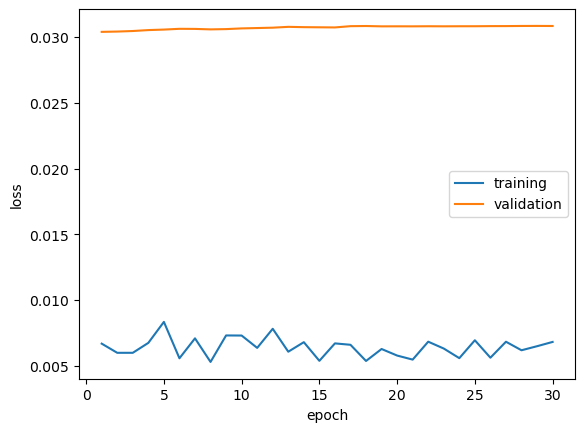

In [114]:
from experiment.finetuning.utils import get_training_losses
run_dir = Path(os.path.abspath('')) / 'runs' / f'basin_{basin}'
config_file_path = run_dir / 'config.yml'
fine_model = TrainedModel(config_file_path_or_experiment_name=config_file_path)
training_losses, validation_losses = get_training_losses(fine_model)
plt.plot(training_losses.step, training_losses.value, label='training')
plt.plot(validation_losses.step, validation_losses.value, label='validation')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()


In [115]:
from IPython.core.display import display, HTML

finetuned_model = TrainedModel(config_file_path_or_experiment_name=config_file_path)
df_basin = evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='train', bolden_values = True)
df_all = evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='validation', bolden_values = True)
display(HTML(data=df_basin.to_html(escape=False)))
display(HTML(data=df_all.to_html(escape=False)))

2024-09-28 00:01:48,090: Using the model weights from /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/model_epoch030.pt


/tmp/ipykernel_2035728/3388005891.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  3.59it/s]
2024-09-28 00:01:48,375: Stored metrics at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/train/model_epoch030/train_metrics.csv
2024-09-28 00:01:48,375: Stored results at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/train/model_epoch030/train_results.p
2024-09-28 00:01:48,404: Using the model weights from /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/model_epoch030.pt
# Validation: 100%|██████████| 1/1 [00:00<00:00,  3.53it/s]
2024-09-28 00:01:48,692: Stored metrics at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/validation/model_epoch030/validation_metrics.csv
2024-09-28 00:01:48,693: Stored results at /home/admin/Fine-Flood-Forecasts/experiment/finetuning/runs/basin_09505350/validation/model_epoch030/validation_results.p


,Metric,sota_20,basin_09505350
0,NSE (mean),0.917,0.922
1,KGE (mean),0.851,0.954
2,MSE (mean),0.087,0.082
3,NSE (median),0.917,0.922
4,KGE (median),0.851,0.954
5,MSE (median),0.087,0.082


,Metric,sota_20,basin_09505350
0,NSE (mean),0.562,0.552
1,KGE (mean),0.477,0.431
2,MSE (mean),0.69,0.704
3,NSE (median),0.562,0.552
4,KGE (median),0.477,0.431
5,MSE (median),0.69,0.704


In [92]:
df_test = evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='test', bolden_values = True)
display(HTML(data=df_test.to_html(escape=False)))

,Metric,sota_20,basin_07180500
0,NSE (mean),0.719,0.713
1,KGE (mean),0.755,0.741
2,MSE (mean),1.908,1.949
3,NSE (median),0.719,0.713
4,KGE (median),0.755,0.741
5,MSE (median),1.908,1.949


In [21]:
import pandas as pd
model = TrainedModel(TrainedModelID.SOTA_20)
metric = 'NSE'
fine_m = pd.read_csv(os.path.join('assets', model.config_id, 'finetuned_metrics.csv'), index_col='Metric').transpose().reset_index(drop=False).rename(columns={'index': 'basin'})
sota_m = pd.read_csv('../models/runs/sota_20/test/model_epoch030/test_metrics.csv', dtype={'basin':str})


FileNotFoundError: [Errno 2] No such file or directory: 'assets/sota_20/finetuned_metrics.csv'

In [29]:
fine_m = fine_m.map(lambda x: x.replace('<b>', '').replace('</b>',''))


In [30]:
merged_df = pd.merge(left=sota_m[['basin', f'{metric}']], right=fine_m[['basin', f'{metric} (mean)']], on='basin')
merged_df[f'{metric} (mean)'] = merged_df[f'{metric} (mean)'].astype(float)

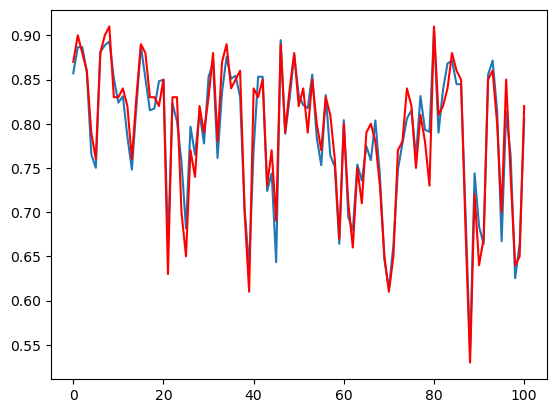

In [31]:
plt.plot(merged_df[f'{metric}'])
plt.plot(merged_df[f'{metric} (mean)'], 'r')


In [32]:
merged_df = merged_df.set_index('basin')

In [33]:
merged_df.mean(axis=0)

NSE           0.787824
NSE (mean)    0.789307
dtype: float64